### ĐỌC DỮ LIỆU

In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Định nghĩa lại hàm để đảm bảo an toàn
def finalize_data(df):
    # Nếu lỡ truyền đường dẫn file vào, hàm sẽ tự đọc file luôn
    if isinstance(df, str):
        df = pd.read_csv(df)
    
    cols_to_drop = ['Transaction Date', 'Device Fingerprint', 'Merchant', 'City','device_transaction_count_1h']
    categorical_cols = ['Product Category', 'Currency', 'Country', 'City Size', 'Card Type']
    
    # Drop các cột thừa
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # Label Encoding
    le = LabelEncoder()
    for col in categorical_cols:
        if col in df.columns:
            # Ép kiểu string và xử lý giá trị thiếu (nếu có) trước khi encode
            df[col] = le.fit_transform(df[col].astype(str))
            
    return df



# 2. Bây giờ bạn chạy lại sẽ không còn lỗi nữa
train_final = finalize_data('engineered_train.csv')
val_final = finalize_data('engineered_val.csv')
test_final = finalize_data('engineered_test.csv')

# Kiểm tra thử
print("Kích thước tập Train mới:", train_final.shape)
print(train_final.head())

Kích thước tập Train mới: (5613123, 26)
   Product Category  Currency  Country  City Size  Card Type  Card Present  \
0                 2         8        8          1          2             0   
1                 2         4       10          1          2             0   
2                 2         8        8          1          2             0   
3                 6         3        4          1          0             0   
4                 5         5        5          1          0             0   

   Distance From Home  High Risk Merchant  Weekend Transaction  \
0                   1                   0                    0   
1                   0                   0                    0   
2                   0                   0                    0   
3                   0                   0                    1   
4                   0                   0                    0   

   Velocity Last Hour  ...  Is_High_Risk_Hour  Night_Mismatch  \
0                 0.0  ...   

In [6]:
# Tính giá trị trung bình và độ lệch chuẩn của số tiền theo từng Category trên tập Train
agg_data = train_final.groupby('Product Category')['Amount USD'].agg(['mean', 'std']).reset_index()
agg_data.columns = ['Product Category', 'category_mean_amt', 'category_std_amt']

def add_zscore(df):
    df = df.merge(agg_data, on='Product Category', how='left')
    # Tính Z-Score: (Giá trị - Trung bình) / Độ lệch chuẩn
    df['amt_zscore_category'] = (df['Amount USD'] - df['category_mean_amt']) / (df['category_std_amt'] + 1e-6)
    return df.drop(columns=['category_mean_amt', 'category_std_amt'])

# Áp dụng cho cả 3 bộ
train_final = add_zscore(train_final)
val_final = add_zscore(val_final)
test_final = add_zscore(test_final)

Các cột bị loại bỏ do tương quan > 0.98: ['Night_Mismatch', 'is_physical_pos_hazard', 'dist_international_ratio']


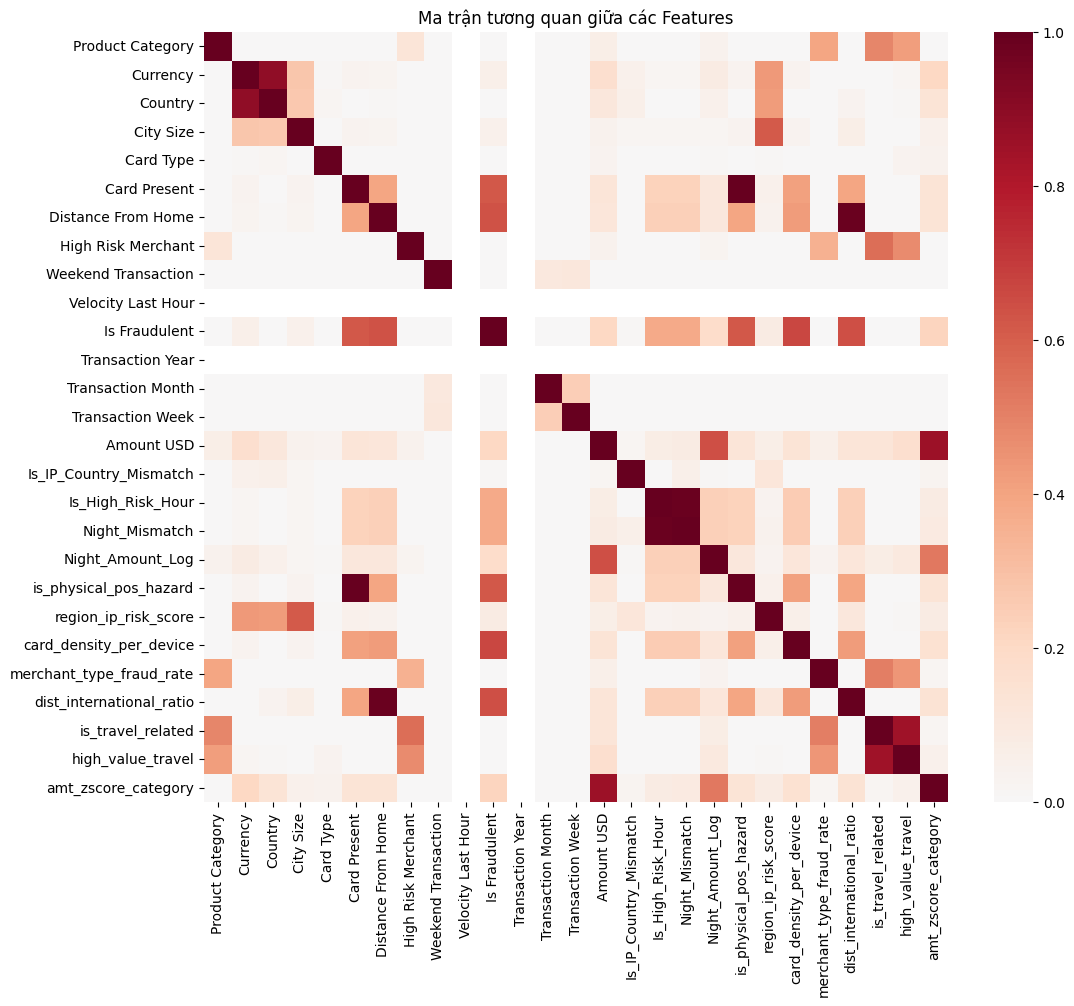

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def drop_high_correlation_features(df, threshold=0.95):
    # 1. Tính ma trận tương quan (chỉ tính trên các cột số)
    corr_matrix = df.corr().abs()

    # 2. Lấy tam giác trên của ma trận tương quan (để tránh lặp lại các cặp)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # 3. Tìm danh sách các cột có độ tương quan vượt ngưỡng threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f"Các cột bị loại bỏ do tương quan > {threshold}: {to_drop}")
    
    # 4. Drop các cột đó
    df_dropped = df.drop(columns=to_drop)
    
    return df_dropped, corr_matrix

# --- Áp dụng ---
# Lưu ý: Chỉ nên chạy trên tập TRAIN để tìm các cột cần drop, sau đó áp dụng cùng danh sách cho Val và Test
train_final, full_corr_matrix = drop_high_correlation_features(train_final, threshold=0.98)

# Cập nhật tập Val và Test theo cùng danh sách cột của Train
val_final = val_final[train_final.columns]
test_final = test_final[train_final.columns]

# --- Trực quan hóa (Tùy chọn) ---
plt.figure(figsize=(12, 10))
sns.heatmap(full_corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title("Ma trận tương quan giữa các Features")
plt.show()

In [7]:
# 1. Danh sách các cột cần loại bỏ dựa trên phân tích tương quan
cols_to_remove = ['Night_Mismatch', 'is_physical_pos_hazard', 'dist_international_ratio']

# 2. Hàm loại bỏ cột an toàn
def drop_redundant_features(df, drop_list):
    # Chỉ loại bỏ những cột thực sự có mặt trong DataFrame
    existing_cols_to_drop = [c for c in drop_list if c in df.columns]
    return df.drop(columns=existing_cols_to_drop)

# 3. Áp dụng cho cả 3 bộ dữ liệu
train_final = drop_redundant_features(train_final, cols_to_remove)
val_final = drop_redundant_features(val_final, cols_to_remove)
test_final = drop_redundant_features(test_final, cols_to_remove)

In [14]:
train_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5613123 entries, 0 to 5613122
Data columns (total 24 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Product Category          int64  
 1   Currency                  int64  
 2   Country                   int64  
 3   City Size                 int64  
 4   Card Type                 int64  
 5   Card Present              int64  
 6   Distance From Home        int64  
 7   High Risk Merchant        int64  
 8   Weekend Transaction       int64  
 9   Velocity Last Hour        float64
 10  Is Fraudulent             int64  
 11  Transaction Year          int64  
 12  Transaction Month         int64  
 13  Transaction Week          int64  
 14  Amount USD                float64
 15  Is_IP_Country_Mismatch    int64  
 16  Is_High_Risk_Hour         int64  
 17  Night_Amount_Log          float64
 18  region_ip_risk_score      float64
 19  card_density_per_device   int64  
 20  merchant_type_fraud_rate

### Huấn Luyện Mô Hình

In [8]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# Tách Features và Target
X_train = train_final.drop(columns=['Is Fraudulent'])
y_train = train_final['Is Fraudulent']

# Tính scale_pos_weight để xử lý mất cân bằng
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import xgboost as xgb

# 1. Lấy mẫu 10% từ tập Train (Đảm bảo tỉ lệ Is Fraudulent không đổi)
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, 
    test_size=0.8,           
    stratify=y_train,        
    random_state=42
)

print(f"Kích thước mẫu để dò tham số: {X_train_sample.shape}")

# 2. Thiết lập GridSearchCV (Sử dụng n_jobs=1 để an toàn tuyệt đối cho RAM)
xgb_model = xgb.XGBClassifier(
    tree_method='hist', 
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    verbose=2,
    n_jobs=1 # Chạy tuần tự để không tốn RAM
)

# 3. Chạy trên MẪU
grid_search.fit(X_train_sample, y_train_sample)

print(f"Tham số tốt nhất từ mẫu: {grid_search.best_params_}")

Kích thước mẫu để dò tham số: (1122624, 23)
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=100; total time=   1.7s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=100; total time=   1.5s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=100; total time=   1.5s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=200; total time=   2.4s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=200; total time=   2.5s
[CV] END ..learning_rate=0.05, max_depth=4, n_estimators=200; total time=   2.4s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=100; total time=   1.8s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=100; total time=   1.8s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=100; total time=   1.8s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=200; total time=   3.2s
[CV] END ..learning_rate=0.05, max_depth=6, n_estimators=200; total time=   3.4s
[CV]

In [10]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
# Tập Validation (Đây là cái bị thiếu gây lỗi NameError)
X_val = val_final.drop(columns=['Is Fraudulent'])
y_val = val_final['Is Fraudulent']


# 1. Định nghĩa lại tham số tốt nhất bạn vừa tìm được
best_params = {
    'learning_rate': 0.05,
    'max_depth': 8,
    'n_estimators': 2000,# Ta có thể tăng lên vì có early_stopping gác cổng
    'gamma': 0.2, # Thêm trọng số phạt
    'tree_method': 'hist',
    'random_state': 42,
    'scale_pos_weight': scale_pos_weight # Biến này bạn đã tính ở bước trước
}

# 2. Khởi tạo model với bộ tham số "vàng"
final_model = xgb.XGBClassifier(**best_params, early_stopping_rounds=20)

# 3. Huấn luyện trên 100% dữ liệu Train
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50 # Cứ 50 vòng lặp thì báo cáo kết quả 1 lần
)

print("\n ĐÃ HUẤN LUYỆN XONG ")

[0]	validation_0-logloss:0.65215
[50]	validation_0-logloss:0.14456
[100]	validation_0-logloss:0.10765
[150]	validation_0-logloss:0.08709
[200]	validation_0-logloss:0.08400
[215]	validation_0-logloss:0.08437

 ĐÃ HUẤN LUYỆN XONG 


In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
# --- 1. CHUẨN BỊ DỮ LIỆU ---
X_val = val_final.drop(columns=['Is Fraudulent'])
y_val = val_final['Is Fraudulent']
X_test = test_final.drop(columns=['Is Fraudulent'])
y_test = test_final['Is Fraudulent']

# --- 2. DỰ BÁO XÁC SUẤT (PROBABILITY) ---
y_val_proba = final_model.predict_proba(X_val)[:, 1]
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# --- 3. TÌM NGƯỠNG (THRESHOLD) TỐI ƯU TRÊN TẬP VALIDATION ---
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores_list = [f1_score(y_val, (y_val_proba > t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores_list)]

print(f"Ngưỡng tối ưu tìm được từ tập Validation: {best_threshold:.2f}")
print(f"F1-score cao nhất trên tập Validation: {max(f1_scores_list):.4f}")

# --- 4. ÁP DỤNG NGƯỠNG TỐI ƯU LÊN TẬP TEST ---
y_test_pred_optimized = (y_test_proba > best_threshold).astype(int)

# --- 5. IN BÁO CÁO PHÂN LOẠI CUỐI CÙNG ---
print("\n" + "="*45)
print("KẾT QUẢ PHÂN LOẠI TRÊN TẬP TEST (VỚI NGƯỠNG TỐI ƯU)")
print("="*45)
print(classification_report(y_test, y_test_pred_optimized))

# Chỉ số AUC (Không phụ thuộc vào ngưỡng)
auc_score = roc_auc_score(y_test, y_test_proba)
print(f"Chỉ số ROC-AUC: {auc_score:.4f}")

Ngưỡng tối ưu tìm được từ tập Validation: 0.61
F1-score cao nhất trên tập Validation: 0.9284

KẾT QUẢ PHÂN LOẠI TRÊN TẬP TEST (VỚI NGƯỠNG TỐI ƯU)
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    898357
           1       0.96      0.92      0.93    224208

    accuracy                           0.97   1122565
   macro avg       0.97      0.95      0.96   1122565
weighted avg       0.97      0.97      0.97   1122565

Chỉ số ROC-AUC: 0.9934


<Figure size 1000x800 with 0 Axes>

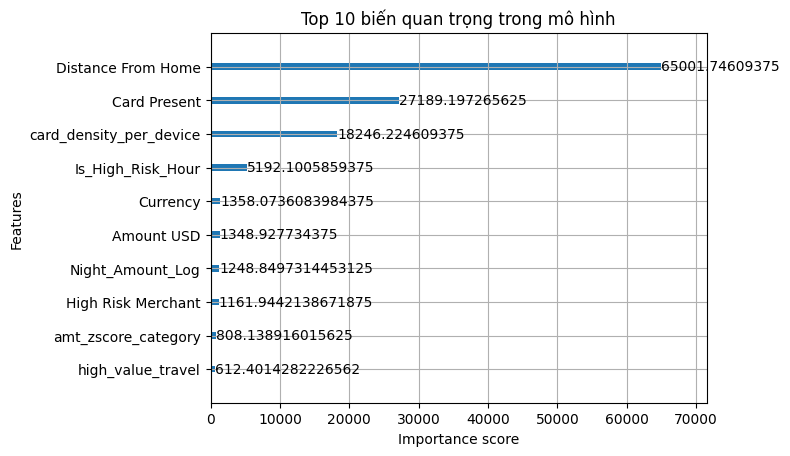

In [12]:
import matplotlib.pyplot as plt

# Xem biến nào đang nắm quyền sinh quyền sát
plt.figure(figsize=(10, 8))
xgb.plot_importance(final_model, max_num_features=10, importance_type='gain')
plt.title("Top 10 biến quan trọng trong mô hình")
plt.show()

In [13]:
import joblib

# 1. Lưu mô hình XGBoost cuối cùng
joblib.dump(final_model, 'xgboost_fraud_model.pkl')

# 2. Lưu bảng thống kê để tính Z-score (Rất quan trọng cho UI)
# Giả sử stats là bảng tính Mean/Std theo Product Category bạn đã làm ở các bước trước
stats_dict = train_final.groupby('Product Category')['Amount USD'].agg(['mean', 'std']).to_dict()
joblib.dump(stats_dict, 'category_stats.pkl')

# 3. Lưu danh sách các cột (Features) theo đúng thứ tự
# Điều này đảm bảo khi dùng UI, ta không bao giờ bị lệch thứ tự cột
model_features = X_train.columns.tolist()
joblib.dump(model_features, 'model_features.pkl')

print("--- Đã đóng gói xong toàn bộ Model và Logic! ---")

--- Đã đóng gói xong toàn bộ Model và Logic! ---
